# 2.3.1 Transpilation Stages in Qiskit

A transpiler works by applying a sequence of "passes"—individual rules, transformations, and analyses applied to the circuit. In Qiskit, this pipeline is orchestrated by a **Pass Manager** that generally moves through **6 standardized stages** to fully prepare the circuit for the hardware.

Think of these stages as a step-by-step assembly line:

| Stage | Name | Purpose |
|-------|------|--------|
| 1 | **Init** | Parse circuit, apply device-independent optimizations |
| 2 | **Layout** | Map logical qubits to physical qubits |
| 3 | **Routing** | Insert SWAP gates to satisfy connectivity constraints |
| 4 | **Translation** | Convert gates to hardware's native gate set (ISA) |
| 5 | **Optimization** | Shrink circuit by merging/canceling redundant gates |
| 6 | **Scheduling** | Time gate execution, insert delays/DD pulses |

## Setup and Imports

In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

  Using cached pylatexenc-2.10.tar.gz (162 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 2.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 1.6 MB/s  0:00:04 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.4 MB/s  0:00:02 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136897 sha256=f69487e63c1e22f57258036aeb578a15652193c6a763dc225c5da215ded1fbaf
  Stored in directory: /Users/durutomruk/Library/Caches/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built pylatexenc
   ━━━━━━━

In [2]:
# Install required packages if needed

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Qiskit imports
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import XGate, HGate, CXGate, RZGate, SXGate
from qiskit.transpiler import CouplingMap, PassManager, InstructionDurations
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout, dag_drawer
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.providers.fake_provider import GenericBackendV2

print("Setup complete!")

Setup complete!


## Helper Functions for Visualization

In [3]:
def draw_coupling_map(coupling_map, qubit_labels=None, title="Coupling Map", 
                      highlight_qubits=None, highlight_edges=None, ax=None):
    """
    Draw a coupling map with optional highlighting.
    
    Parameters:
        coupling_map: Qiskit CouplingMap
        qubit_labels: dict mapping physical qubits to labels (e.g., {0: 'q0', 1: 'q1'})
        title: plot title
        highlight_qubits: list of qubits to highlight
        highlight_edges: list of (q1, q2) tuples to highlight
        ax: matplotlib axes to draw on
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Get number of qubits
    n_qubits = coupling_map.size()
    
    # Position qubits in a line for our 3-qubit example
    positions = {i: (i * 2, 0) for i in range(n_qubits)}
    
    # Draw edges first (so nodes appear on top)
    edge_list = coupling_map.get_edges()
    for edge in edge_list:
        q1, q2 = edge
        x1, y1 = positions[q1]
        x2, y2 = positions[q2]
        
        # Check if edge should be highlighted
        edge_color = '#E74C3C' if highlight_edges and (edge in highlight_edges or (q2, q1) in highlight_edges) else '#95A5A6'
        edge_width = 4 if highlight_edges and (edge in highlight_edges or (q2, q1) in highlight_edges) else 2
        
        ax.plot([x1, x2], [y1, y2], color=edge_color, linewidth=edge_width, zorder=1)
    
    # Draw nodes
    for qubit, (x, y) in positions.items():
        # Check if qubit should be highlighted
        if highlight_qubits and qubit in highlight_qubits:
            color = '#3498DB'
            edge_color = '#2980B9'
        else:
            color = '#ECF0F1'
            edge_color = '#7F8C8D'
        
        circle = Circle((x, y), 0.4, facecolor=color, edgecolor=edge_color, 
                        linewidth=2, zorder=2)
        ax.add_patch(circle)
        
        # Add label
        label = qubit_labels.get(qubit, f'Q{qubit}') if qubit_labels else f'Q{qubit}'
        ax.text(x, y, label, ha='center', va='center', fontsize=12, fontweight='bold', zorder=3)
    
    ax.set_xlim(-1, (n_qubits - 1) * 2 + 1)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    return ax


def compare_circuits(circuit1, circuit2, title1="Before", title2="After", figsize=(14, 5)):
    """
    Display two circuits side by side for comparison.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Draw first circuit
    circuit1.draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FFFFFF'})
    ax1.set_title(title1, fontsize=14, fontweight='bold', pad=10)
    
    # Draw second circuit  
    circuit2.draw(output='mpl', ax=ax2, style={'backgroundcolor': '#FFFFFF'})
    ax2.set_title(title2, fontsize=14, fontweight='bold', pad=10)
    
    plt.tight_layout()
    return fig


def show_circuit_stats(circuit, label="Circuit"):
    """
    Print statistics about a circuit.
    """
    print(f"\n{label} Statistics:")
    print(f"  • Depth: {circuit.depth()}")
    print(f"  • Gate count: {sum(circuit.count_ops().values())}")
    print(f"  • Gate types: {dict(circuit.count_ops())}")
    print(f"  • Qubits: {circuit.num_qubits}")


print("Helper functions loaded!")

Helper functions loaded!


## Create the Example Circuit

We'll create a 3-qubit circuit that demonstrates all transpilation stages:
- Two consecutive X gates on q2 (will be optimized away)
- A Hadamard (H) gate (will be translated to native gates)
- An Rz(-π/2) rotation (will merge with translated H)
- CNOT gates connecting qubits that aren't physically adjacent

Original Circuit (before transpilation):


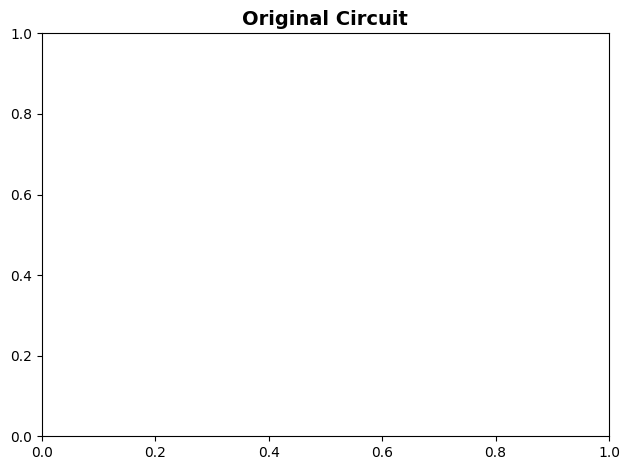


Original Circuit Statistics:
  • Depth: 5
  • Gate count: 7
  • Gate types: {'cx': 3, 'x': 2, 'h': 1, 'rz': 1}
  • Qubits: 3


In [4]:
# Create the example circuit
qc_original = QuantumCircuit(3, name='original')

# Two consecutive X gates on q2 (X·X = I, should be optimized away)
qc_original.x(2)
qc_original.x(2)

# Hadamard gate (needs translation to native gates)
qc_original.h(0)

# Rz rotation (will merge with H's translation)
qc_original.rz(-np.pi/2, 0)

# CNOT gates connecting all qubits
qc_original.cx(0, 1)  # q0 controls q1 (adjacent - OK)
qc_original.cx(0, 2)  # q0 controls q2 (NOT adjacent - needs routing!)
qc_original.cx(1, 2)  # q1 controls q2 (adjacent - OK)

# Visualize the original circuit
print("Original Circuit (before transpilation):")
print("="*50)
qc_original.draw(output='mpl', style={'backgroundcolor': '#FFFFFF', 'fontsize': 12})
plt.title('Original Circuit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

show_circuit_stats(qc_original, "Original Circuit")

## Define the Hardware Backend

We'll create a simple 3-qubit backend with a **linear coupling map**: Q0 — Q1 — Q2

This means:
- Q0 can interact with Q1 ✓
- Q1 can interact with Q0 and Q2 ✓
- Q0 **cannot** directly interact with Q2 ✗ (they need routing!)

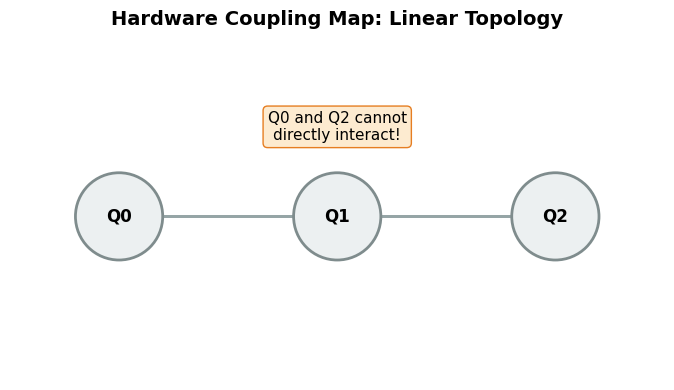


Backend Properties:
  • Number of qubits: 3
  • Native gates (ISA): ['cx', 'id', 'rz', 'sx', 'x', 'reset', 'delay', 'measure']
  • Coupling map edges: EdgeList[(0, 1), (1, 0), (1, 2), (2, 1)]


In [5]:
# Define linear coupling map: Q0 -- Q1 -- Q2
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])

# Create a fake backend with this coupling map
# Native gates: CX, ID, RZ, SX, X (typical IBM basis gates)
backend = GenericBackendV2(
    num_qubits=3,
    coupling_map=coupling_map,
    basis_gates=['cx', 'id', 'rz', 'sx', 'x'],
    seed=42
)

# Visualize the coupling map
fig, ax = plt.subplots(figsize=(10, 4))
draw_coupling_map(coupling_map, title="Hardware Coupling Map: Linear Topology", ax=ax)

# Add annotation
ax.annotate('Q0 and Q2 cannot\ndirectly interact!', 
            xy=(2, 0.7), fontsize=11, ha='center',
            bbox=dict(boxstyle='round', facecolor='#FDEBD0', edgecolor='#E67E22'))

plt.tight_layout()
plt.show()

print(f"\nBackend Properties:")
print(f"  • Number of qubits: {backend.num_qubits}")
print(f"  • Native gates (ISA): {backend.operation_names}")
print(f"  • Coupling map edges: {coupling_map.get_edges()}")

---
# Stage 1: Init (Initialization / High-Level Optimization)

The circuit is parsed, and **device-independent optimizations** are applied:
- Unroll complex mathematical operators
- Cancel obvious redundant gates (like X·X = I)

**In our example:** The two consecutive X gates on q2 are recognized as X·X = I and removed!

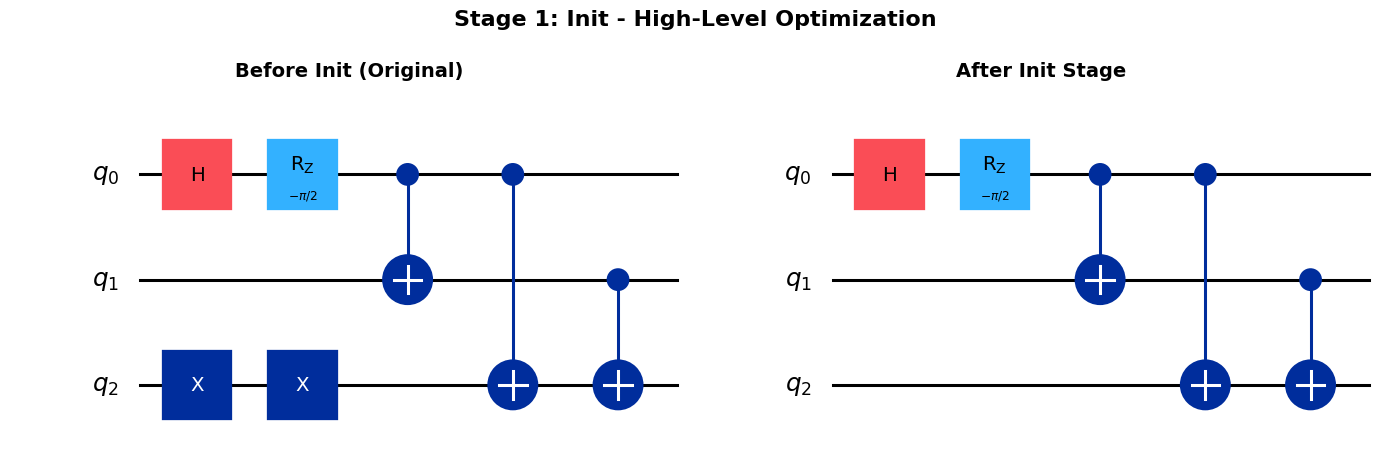


STAGE 1: INIT - What happened?
✓ Two consecutive X gates on q2 were recognized as X·X = I
✓ These gates were REMOVED (they cancel each other out)

This is a device-independent optimization - it applies to any hardware!

Before Init Statistics:
  • Depth: 5
  • Gate count: 7
  • Gate types: {'cx': 3, 'x': 2, 'h': 1, 'rz': 1}
  • Qubits: 3

After Init Statistics:
  • Depth: 5
  • Gate count: 5
  • Gate types: {'cx': 3, 'h': 1, 'rz': 1}
  • Qubits: 3


In [6]:
# Create a pass manager for just the init stage
pm_init = generate_preset_pass_manager(
    optimization_level=2,
    backend=backend
)

# Run only the init stage (stages are PassManager objects, use .run())
qc_after_init = pm_init.init.run(qc_original)

# Visualize the transformation
fig = compare_circuits(
    qc_original, qc_after_init,
    "Before Init (Original)", "After Init Stage",
    figsize=(14, 5)
)
plt.suptitle('Stage 1: Init - High-Level Optimization', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n" + "="*60)
print("STAGE 1: INIT - What happened?")
print("="*60)
print("✓ Two consecutive X gates on q2 were recognized as X·X = I")
print("✓ These gates were REMOVED (they cancel each other out)")
print("\nThis is a device-independent optimization - it applies to any hardware!")

show_circuit_stats(qc_original, "Before Init")
show_circuit_stats(qc_after_init, "After Init")

---
# Stage 2: Layout

The transpiler assigns **logical qubits** (from your program) to **physical qubits** on the chip.

**In our example:** 
- Logical qubit q0 → Physical qubit Q0
- Logical qubit q1 → Physical qubit Q1  
- Logical qubit q2 → Physical qubit Q2

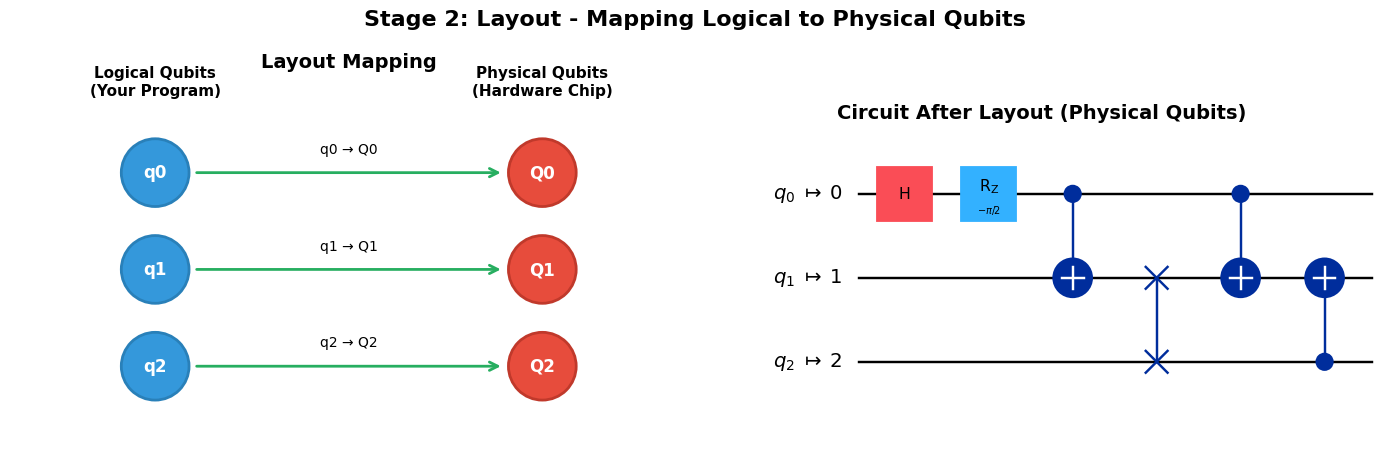


STAGE 2: LAYOUT - What happened?
✓ Logical qubits (q0, q1, q2) mapped to physical qubits (Q0, Q1, Q2)
✓ The transpiler chose a trivial 1-to-1 mapping here

Note: For larger circuits, the layout choice can significantly
impact performance based on connectivity and error rates!


In [8]:
# Run layout stage
qc_after_layout = pm_init.layout.run(qc_after_init)

# Visualize the layout mapping
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Show the logical-to-physical mapping
ax1.set_xlim(-1, 6)
ax1.set_ylim(-2, 2)

# Draw logical qubits (left side)
logical_y = [1, 0, -1]
for i, y in enumerate(logical_y):
    circle = Circle((0.5, y), 0.35, facecolor='#3498DB', edgecolor='#2980B9', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(0.5, y, f'q{i}', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax1.text(0.5, 1.8, 'Logical Qubits\n(Your Program)', ha='center', fontsize=11, fontweight='bold')

# Draw physical qubits (right side)
physical_y = [1, 0, -1]
for i, y in enumerate(physical_y):
    circle = Circle((4.5, y), 0.35, facecolor='#E74C3C', edgecolor='#C0392B', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(4.5, y, f'Q{i}', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax1.text(4.5, 1.8, 'Physical Qubits\n(Hardware Chip)', ha='center', fontsize=11, fontweight='bold')

# Draw mapping arrows
for i, (ly, py) in enumerate(zip(logical_y, physical_y)):
    arrow = FancyArrowPatch((0.9, ly), (4.1, py),
                            arrowstyle='->', mutation_scale=15,
                            color='#27AE60', linewidth=2)
    ax1.add_patch(arrow)
    ax1.text(2.5, (ly + py)/2 + 0.2, f'q{i} → Q{i}', fontsize=10, ha='center')

ax1.axis('off')
ax1.set_aspect('equal')
ax1.set_title('Layout Mapping', fontsize=14, fontweight='bold')

# Right: Show the circuit with physical qubits
qc_after_layout.draw(output='mpl', ax=ax2, style={'backgroundcolor': '#FFFFFF'})
ax2.set_title('Circuit After Layout (Physical Qubits)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.suptitle('Stage 2: Layout - Mapping Logical to Physical Qubits', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n" + "="*60)
print("STAGE 2: LAYOUT - What happened?")
print("="*60)
print("✓ Logical qubits (q0, q1, q2) mapped to physical qubits (Q0, Q1, Q2)")
print("✓ The transpiler chose a trivial 1-to-1 mapping here")
print("\nNote: For larger circuits, the layout choice can significantly")
print("impact performance based on connectivity and error rates!")

---
# Stage 3: Routing

Physical qubits can only interact with their **immediate neighbors** based on the coupling map. If your program requires two unconnected qubits to interact, this stage inserts **SWAP gates** to move quantum information.

**In our example:**
- Our program has a CX(q0, q2) gate, but Q0 and Q2 are NOT connected!
- The routing stage must insert SWAP gates to enable this interaction.

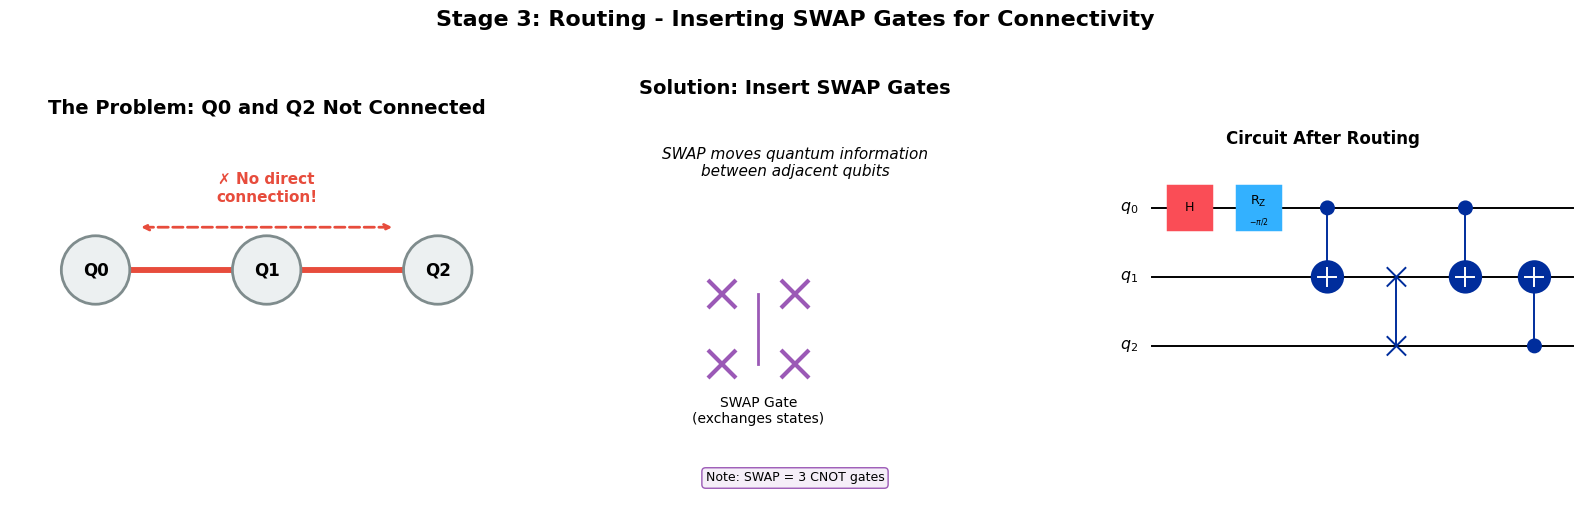


STAGE 3: ROUTING - What happened?
✓ The CX(Q0, Q2) gate required non-adjacent qubits to interact
✓ SWAP gates were inserted to move quantum states to adjacent positions
✓ Each SWAP gate decomposes into 3 CNOT gates

⚠️  Routing increases circuit depth and gate count!

Before Routing Statistics:
  • Depth: 6
  • Gate count: 6
  • Gate types: {'cx': 3, 'h': 1, 'rz': 1, 'swap': 1}
  • Qubits: 3

After Routing Statistics:
  • Depth: 6
  • Gate count: 6
  • Gate types: {'cx': 3, 'h': 1, 'rz': 1, 'swap': 1}
  • Qubits: 3


In [9]:
# Run routing stage
qc_after_routing = pm_init.routing.run(qc_after_layout)

# Visualize the problem and solution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Show the connectivity problem
ax1 = axes[0]
draw_coupling_map(coupling_map, 
                  qubit_labels={0: 'Q0', 1: 'Q1', 2: 'Q2'},
                  title="The Problem: Q0 and Q2 Not Connected",
                  highlight_edges=[(0, 1), (1, 2)],
                  ax=ax1)

# Add X mark between Q0 and Q2
ax1.text(2, 0.8, '✗ No direct\nconnection!', fontsize=11, ha='center', 
        color='#E74C3C', fontweight='bold')
ax1.annotate('', xy=(0.5, 0.5), xytext=(3.5, 0.5),
            arrowprops=dict(arrowstyle='<->', color='#E74C3C', lw=2, ls='--'))

# Panel 2: Show SWAP gate insertion
ax2 = axes[1]
ax2.set_xlim(-1, 6)
ax2.set_ylim(-1.5, 2.5)

# Draw explanation
ax2.text(2.5, 2, 'Solution: Insert SWAP Gates', fontsize=14, fontweight='bold', ha='center')
ax2.text(2.5, 1.3, 'SWAP moves quantum information\nbetween adjacent qubits', 
        fontsize=11, ha='center', style='italic')

# Draw SWAP gate symbol
ax2.plot([1.5, 2.5], [0.3, -0.3], 'x', markersize=20, color='#9B59B6', mew=3)
ax2.plot([1.5, 2.5], [-0.3, 0.3], 'x', markersize=20, color='#9B59B6', mew=3)
ax2.plot([2, 2], [0.3, -0.3], color='#9B59B6', linewidth=2)

ax2.text(2, -0.8, 'SWAP Gate\n(exchanges states)', fontsize=10, ha='center')

# Note about SWAP decomposition
ax2.text(2.5, -1.3, 'Note: SWAP = 3 CNOT gates', fontsize=9, ha='center', 
        bbox=dict(boxstyle='round', facecolor='#F5EEF8', edgecolor='#9B59B6'))

ax2.axis('off')

# Panel 3: Show the routed circuit
ax3 = axes[2]
qc_after_routing.draw(output='mpl', ax=ax3, style={'backgroundcolor': '#FFFFFF'})
ax3.set_title('Circuit After Routing', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('Stage 3: Routing - Inserting SWAP Gates for Connectivity', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n" + "="*60)
print("STAGE 3: ROUTING - What happened?")
print("="*60)
print("✓ The CX(Q0, Q2) gate required non-adjacent qubits to interact")
print("✓ SWAP gates were inserted to move quantum states to adjacent positions")
print("✓ Each SWAP gate decomposes into 3 CNOT gates")
print("\n⚠️  Routing increases circuit depth and gate count!")

show_circuit_stats(qc_after_layout, "Before Routing")
show_circuit_stats(qc_after_routing, "After Routing")

---
# Stage 4: Translation (Synthesis)

The transpiler converts high-level gates into the hardware's **native gate set** (the ISA).

**Our hardware's native gates:** CX, ID, RZ, SX, X

**In our example:**
- The H (Hadamard) gate is NOT native
- It must be translated into a sequence of RZ and SX gates

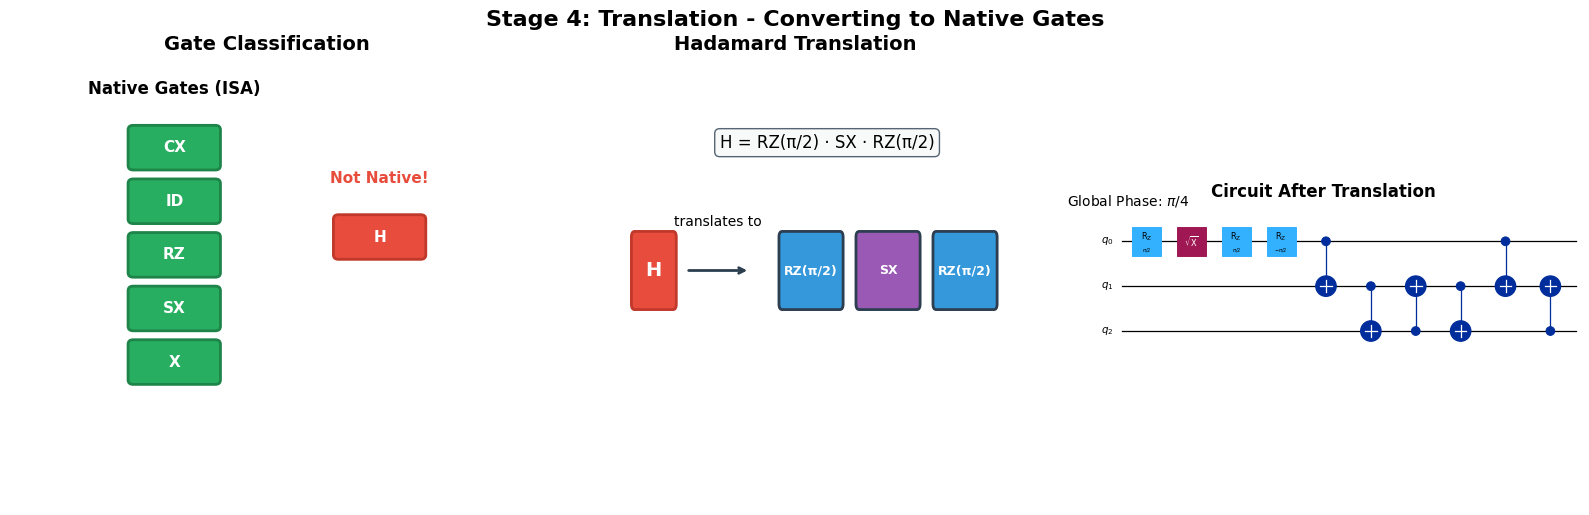


STAGE 4: TRANSLATION - What happened?
✓ The H (Hadamard) gate was translated to: RZ(π/2) · SX · RZ(π/2)
✓ All SWAP gates decomposed into sequences of 3 CX gates each
✓ All gates are now in the native gate set: {CX, ID, RZ, SX, X}

After Translation Statistics:
  • Depth: 10
  • Gate count: 10
  • Gate types: {'cx': 6, 'rz': 3, 'sx': 1}
  • Qubits: 3

Gate types now: {'cx': 6, 'rz': 3, 'sx': 1}


In [10]:
# Run translation stage
qc_after_translation = pm_init.translation.run(qc_after_routing)

# Create visualization showing H gate translation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: What gates need translation
ax1 = axes[0]
ax1.set_xlim(-1, 4)
ax1.set_ylim(-1, 4)

# Native gates
native_gates = ['CX', 'ID', 'RZ', 'SX', 'X']
for i, gate in enumerate(native_gates):
    y = 3 - i * 0.6
    rect = FancyBboxPatch((0.2, y - 0.2), 0.8, 0.4,
                          boxstyle="round,pad=0.05",
                          facecolor='#27AE60', edgecolor='#1E8449', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(0.6, y, gate, fontsize=11, ha='center', va='center', 
            color='white', fontweight='bold')

ax1.text(0.6, 3.6, 'Native Gates (ISA)', fontsize=12, fontweight='bold', ha='center')

# Non-native gate
rect = FancyBboxPatch((2.2, 1.8), 0.8, 0.4,
                      boxstyle="round,pad=0.05",
                      facecolor='#E74C3C', edgecolor='#C0392B', linewidth=2)
ax1.add_patch(rect)
ax1.text(2.6, 2, 'H', fontsize=11, ha='center', va='center', 
        color='white', fontweight='bold')
ax1.text(2.6, 2.6, 'Not Native!', fontsize=11, ha='center', color='#E74C3C', fontweight='bold')

ax1.axis('off')
ax1.set_title('Gate Classification', fontsize=14, fontweight='bold')

# Panel 2: H gate decomposition
ax2 = axes[1]
ax2.set_xlim(-1, 7)
ax2.set_ylim(-1, 3)

# H gate
rect = FancyBboxPatch((0.5, 0.8), 0.6, 0.6,
                      boxstyle="round,pad=0.05",
                      facecolor='#E74C3C', edgecolor='#C0392B', linewidth=2)
ax2.add_patch(rect)
ax2.text(0.8, 1.1, 'H', fontsize=14, ha='center', va='center', 
        color='white', fontweight='bold')

# Arrow
ax2.annotate('', xy=(2.3, 1.1), xytext=(1.3, 1.1),
            arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=2))
ax2.text(1.8, 1.5, 'translates to', fontsize=10, ha='center')

# RZ-SX-RZ sequence
gates = [('RZ(π/2)', '#3498DB'), ('SX', '#9B59B6'), ('RZ(π/2)', '#3498DB')]
for i, (gate, color) in enumerate(gates):
    x = 2.8 + i * 1.2
    rect = FancyBboxPatch((x, 0.8), 0.9, 0.6,
                          boxstyle="round,pad=0.05",
                          facecolor=color, edgecolor='#2C3E50', linewidth=2)
    ax2.add_patch(rect)
    ax2.text(x + 0.45, 1.1, gate, fontsize=9, ha='center', va='center', 
            color='white', fontweight='bold')

ax2.text(3.5, 2.2, 'H = RZ(π/2) · SX · RZ(π/2)', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='#F8F9F9', edgecolor='#566573'))

ax2.axis('off')
ax2.set_title('Hadamard Translation', fontsize=14, fontweight='bold')

# Panel 3: Translated circuit
ax3 = axes[2]
qc_after_translation.draw(output='mpl', ax=ax3, style={'backgroundcolor': '#FFFFFF'}, fold=-1)
ax3.set_title('Circuit After Translation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('Stage 4: Translation - Converting to Native Gates', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n" + "="*60)
print("STAGE 4: TRANSLATION - What happened?")
print("="*60)
print("✓ The H (Hadamard) gate was translated to: RZ(π/2) · SX · RZ(π/2)")
print("✓ All SWAP gates decomposed into sequences of 3 CX gates each")
print("✓ All gates are now in the native gate set: {CX, ID, RZ, SX, X}")

show_circuit_stats(qc_after_translation, "After Translation")
print(f"\nGate types now: {dict(qc_after_translation.count_ops())}")

---
# Stage 5: Optimization

The transpiler performs a deep sweep to **shrink the circuit**:
- Merge adjacent single-qubit gates
- Cancel redundant operations
- Commute gates to enable more cancellations

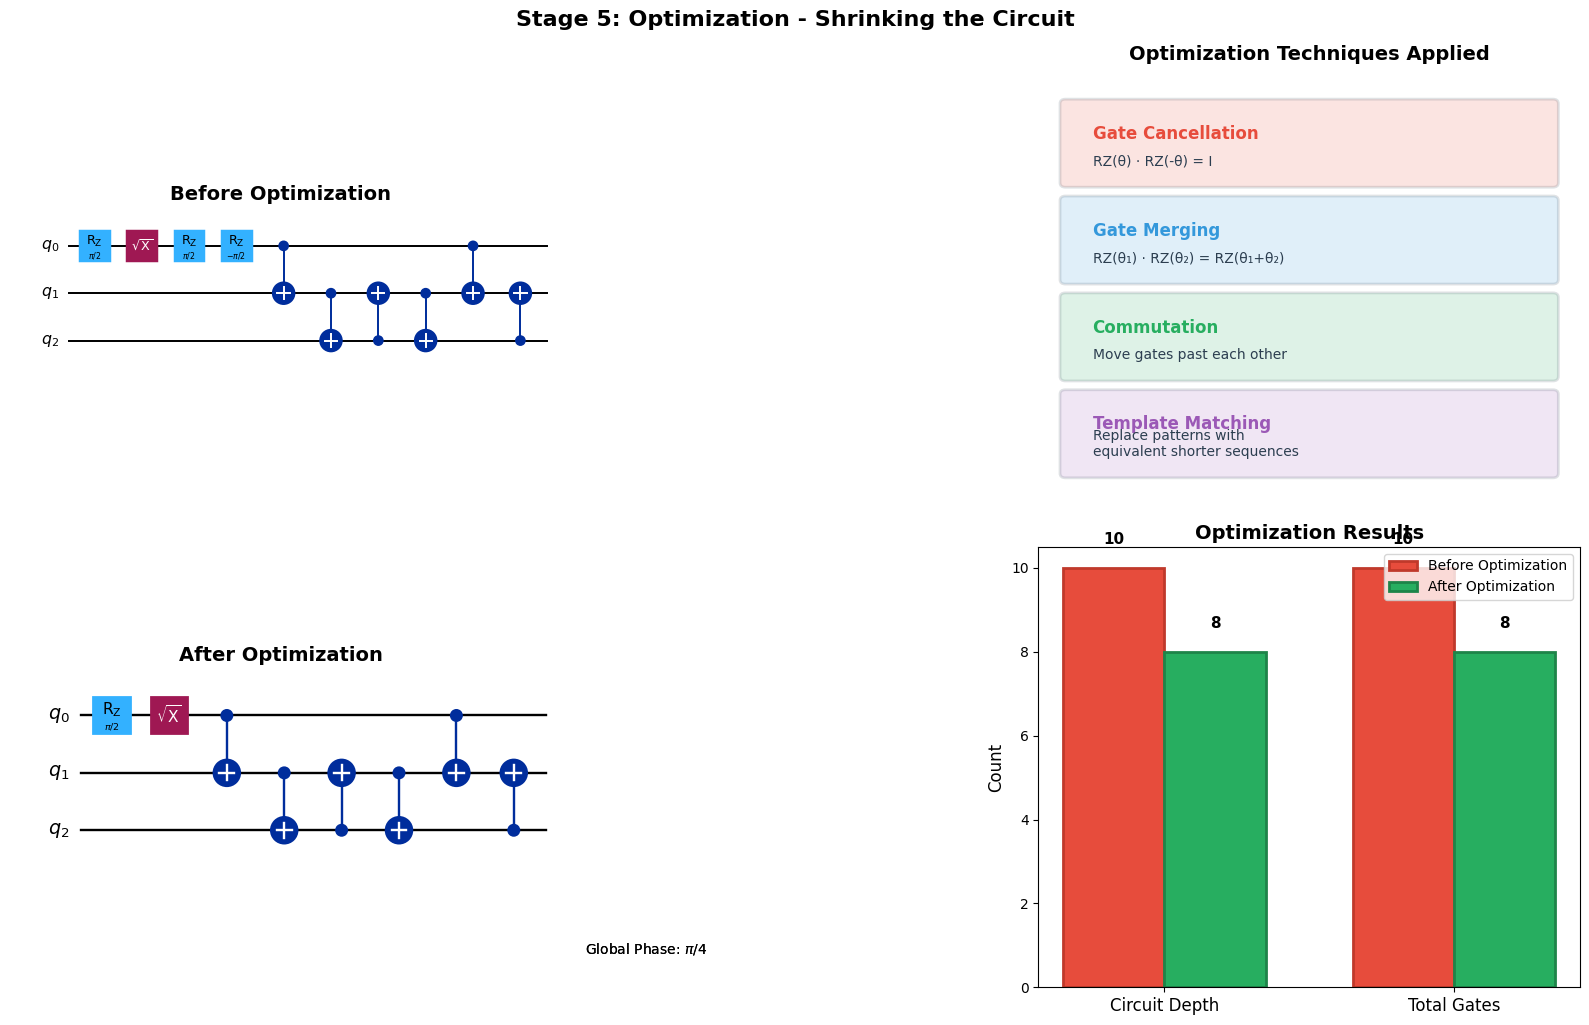


STAGE 5: OPTIMIZATION - What happened?
✓ Circuit depth: 10 → 8 (reduction: 2)
✓ Gate count: 10 → 8 (reduction: 2)

✓ Adjacent RZ gates were merged: RZ(θ₁)·RZ(θ₂) → RZ(θ₁+θ₂)
✓ The Rz(-π/2) from our original circuit merged with translation gates


In [11]:
# Run optimization stage
qc_after_optimization = pm_init.optimization.run(qc_after_translation)

# Visualize the optimization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Before optimization (top left)
ax1 = axes[0, 0]
qc_after_translation.draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FFFFFF'}, fold=-1)
ax1.set_title('Before Optimization', fontsize=14, fontweight='bold')

# Panel 2: Optimization techniques (top right)
ax2 = axes[0, 1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

techniques = [
    ("Gate Cancellation", "RZ(θ) · RZ(-θ) = I", '#E74C3C'),
    ("Gate Merging", "RZ(θ₁) · RZ(θ₂) = RZ(θ₁+θ₂)", '#3498DB'),
    ("Commutation", "Move gates past each other", '#27AE60'),
    ("Template Matching", "Replace patterns with\nequivalent shorter sequences", '#9B59B6'),
]

for i, (name, desc, color) in enumerate(techniques):
    y = 8 - i * 2.2
    rect = FancyBboxPatch((0.5, y - 0.6), 9, 1.8,
                          boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor='#2C3E50', 
                          linewidth=2, alpha=0.15)
    ax2.add_patch(rect)
    
    ax2.text(1, y + 0.4, name, fontsize=12, fontweight='bold', color=color)
    ax2.text(1, y - 0.2, desc, fontsize=10, color='#2C3E50')

ax2.axis('off')
ax2.set_title('Optimization Techniques Applied', fontsize=14, fontweight='bold')

# Panel 3: After optimization (bottom left)
ax3 = axes[1, 0]
qc_after_optimization.draw(output='mpl', ax=ax3, style={'backgroundcolor': '#FFFFFF'}, fold=-1)
ax3.set_title('After Optimization', fontsize=14, fontweight='bold')

# Panel 4: Statistics comparison (bottom right)
ax4 = axes[1, 1]

# Get stats
before_depth = qc_after_translation.depth()
after_depth = qc_after_optimization.depth()
before_gates = sum(qc_after_translation.count_ops().values())
after_gates = sum(qc_after_optimization.count_ops().values())

categories = ['Circuit Depth', 'Total Gates']
before_vals = [before_depth, before_gates]
after_vals = [after_depth, after_gates]

x = np.arange(len(categories))
width = 0.35

bars1 = ax4.bar(x - width/2, before_vals, width, label='Before Optimization', 
               color='#E74C3C', edgecolor='#C0392B', linewidth=2)
bars2 = ax4.bar(x + width/2, after_vals, width, label='After Optimization', 
               color='#27AE60', edgecolor='#1E8449', linewidth=2)

ax4.set_ylabel('Count', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(categories, fontsize=12)
ax4.legend(fontsize=10)
ax4.set_title('Optimization Results', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars1, before_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar, val in zip(bars2, after_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.suptitle('Stage 5: Optimization - Shrinking the Circuit', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n" + "="*60)
print("STAGE 5: OPTIMIZATION - What happened?")
print("="*60)
print(f"✓ Circuit depth: {before_depth} → {after_depth} (reduction: {before_depth - after_depth})")
print(f"✓ Gate count: {before_gates} → {after_gates} (reduction: {before_gates - after_gates})")
print("\n✓ Adjacent RZ gates were merged: RZ(θ₁)·RZ(θ₂) → RZ(θ₁+θ₂)")
print("✓ The Rz(-π/2) from our original circuit merged with translation gates")

---
# Stage 6: Scheduling

The transpiler considers the **exact physical execution time** of gates and schedules when each gate fires. It may insert:
- **Delays** to synchronize operations
- **Dynamical Decoupling (DD) pulses** to protect idle qubits from noise

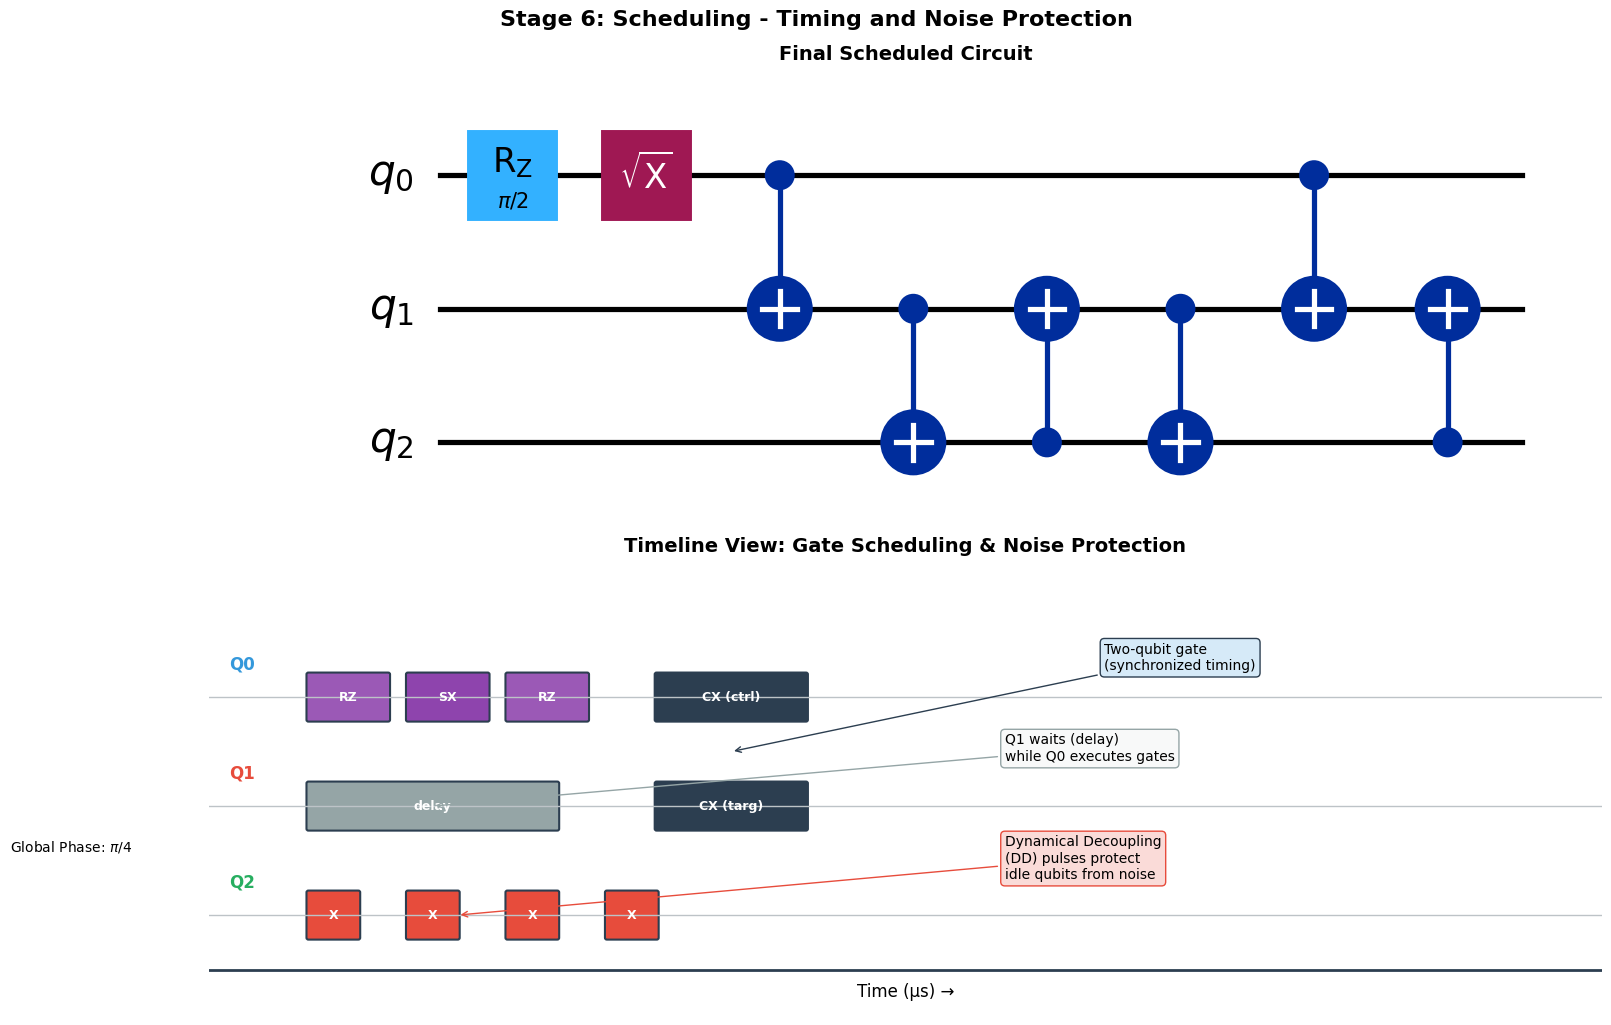


STAGE 6: SCHEDULING - What happened?
✓ Gate execution times calculated (in microseconds)
✓ Delays inserted where qubits must wait
✓ Dynamical Decoupling (DD) pulses added to protect idle qubits

The circuit is now fully transpiled and ready for hardware execution!


In [12]:
# Run scheduling stage
qc_after_scheduling = pm_init.scheduling.run(qc_after_optimization)

# Create a timeline visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel 1: Scheduled circuit
ax1 = axes[0]
qc_after_scheduling.draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FFFFFF'}, fold=-1)
ax1.set_title('Final Scheduled Circuit', fontsize=14, fontweight='bold')

# Panel 2: Timeline explanation
ax2 = axes[1]
ax2.set_xlim(0, 14)
ax2.set_ylim(-1, 4)

# Draw qubit timelines
qubit_colors = ['#3498DB', '#E74C3C', '#27AE60']
for i in range(3):
    y = 2.5 - i * 1.2
    ax2.axhline(y=y, color='#BDC3C7', linewidth=1, linestyle='-')
    ax2.text(0.2, y + 0.3, f'Q{i}', fontsize=12, fontweight='bold', color=qubit_colors[i])

# Draw time axis
ax2.axhline(y=-0.5, color='#2C3E50', linewidth=2)
ax2.text(7, -0.8, 'Time (μs) →', fontsize=12, ha='center')

# Draw example gates and delays on timeline
def draw_gate_block(ax, x, y, width, label, color):
    rect = FancyBboxPatch((x, y - 0.25), width, 0.5,
                          boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='#2C3E50', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + width/2, y, label, fontsize=9, ha='center', va='center', 
           color='white', fontweight='bold')

# Q0 timeline
draw_gate_block(ax2, 1, 2.5, 0.8, 'RZ', '#9B59B6')
draw_gate_block(ax2, 2, 2.5, 0.8, 'SX', '#8E44AD')
draw_gate_block(ax2, 3, 2.5, 0.8, 'RZ', '#9B59B6')
draw_gate_block(ax2, 4.5, 2.5, 1.5, 'CX (ctrl)', '#2C3E50')

# Q1 timeline
draw_gate_block(ax2, 1, 1.3, 2.5, 'delay', '#95A5A6')  # Idle time
draw_gate_block(ax2, 4.5, 1.3, 1.5, 'CX (targ)', '#2C3E50')

# Q2 timeline - with DD pulses
draw_gate_block(ax2, 1, 0.1, 0.5, 'X', '#E74C3C')  # DD pulse
draw_gate_block(ax2, 2, 0.1, 0.5, 'X', '#E74C3C')  # DD pulse
draw_gate_block(ax2, 3, 0.1, 0.5, 'X', '#E74C3C')  # DD pulse
draw_gate_block(ax2, 4, 0.1, 0.5, 'X', '#E74C3C')  # DD pulse

# Add annotations
ax2.annotate('Dynamical Decoupling\n(DD) pulses protect\nidle qubits from noise', 
            xy=(2.5, 0.1), xytext=(8, 0.5),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'),
            bbox=dict(boxstyle='round', facecolor='#FADBD8', edgecolor='#E74C3C'))

ax2.annotate('Q1 waits (delay)\nwhile Q0 executes gates', 
            xy=(2.25, 1.3), xytext=(8, 1.8),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#95A5A6'),
            bbox=dict(boxstyle='round', facecolor='#F8F9F9', edgecolor='#95A5A6'))

ax2.annotate('Two-qubit gate\n(synchronized timing)', 
            xy=(5.25, 1.9), xytext=(9, 2.8),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#2C3E50'),
            bbox=dict(boxstyle='round', facecolor='#D6EAF8', edgecolor='#2C3E50'))

ax2.axis('off')
ax2.set_title('Timeline View: Gate Scheduling & Noise Protection', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.suptitle('Stage 6: Scheduling - Timing and Noise Protection', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\n" + "="*60)
print("STAGE 6: SCHEDULING - What happened?")
print("="*60)
print("✓ Gate execution times calculated (in microseconds)")
print("✓ Delays inserted where qubits must wait")
print("✓ Dynamical Decoupling (DD) pulses added to protect idle qubits")
print("\nThe circuit is now fully transpiled and ready for hardware execution!")

---
# Complete Transpilation Summary

Let's see the complete transformation from our original circuit to the final hardware-ready circuit.

In [ ]:
# Create a comprehensive summary figure
fig = plt.figure(figsize=(18, 14))

# Create grid for layout
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# Original circuit (top left)
ax1 = fig.add_subplot(gs[0, 0])
qc_original.draw(output='mpl', ax=ax1, style={'backgroundcolor': '#FFFFFF'})
ax1.set_title('① Original Circuit', fontsize=12, fontweight='bold', color='#2C3E50')

# After Init (top middle)
ax2 = fig.add_subplot(gs[0, 1])
qc_after_init.draw(output='mpl', ax=ax2, style={'backgroundcolor': '#FFFFFF'})
ax2.set_title('② After Init\n(X·X cancelled)', fontsize=12, fontweight='bold', color='#27AE60')

# After Layout (top right)
ax3 = fig.add_subplot(gs[0, 2])
qc_after_layout.draw(output='mpl', ax=ax3, style={'backgroundcolor': '#FFFFFF'})
ax3.set_title('③ After Layout\n(Physical qubits assigned)', fontsize=12, fontweight='bold', color='#3498DB')

# After Routing (middle left)
ax4 = fig.add_subplot(gs[1, :])
qc_after_routing.draw(output='mpl', ax=ax4, style={'backgroundcolor': '#FFFFFF'}, fold=-1)
ax4.set_title('④ After Routing (SWAP gates inserted for Q0↔Q2 interaction)', 
             fontsize=12, fontweight='bold', color='#E67E22')

# After Translation (middle)
ax5 = fig.add_subplot(gs[2, :])
qc_after_translation.draw(output='mpl', ax=ax5, style={'backgroundcolor': '#FFFFFF'}, fold=-1)
ax5.set_title('⑤ After Translation (All gates converted to native ISA: CX, RZ, SX, X)', 
             fontsize=12, fontweight='bold', color='#9B59B6')

# Final optimized circuit (bottom)
ax6 = fig.add_subplot(gs[3, :])
qc_after_optimization.draw(output='mpl', ax=ax6, style={'backgroundcolor': '#FFFFFF'}, fold=-1)
ax6.set_title('⑥ After Optimization (Merged RZ gates, redundancies removed)', 
             fontsize=12, fontweight='bold', color='#1ABC9C')

plt.suptitle('Complete Transpilation Pipeline: From Abstract Circuit to Hardware-Ready', 
             fontsize=18, fontweight='bold', y=0.98)
plt.show()

# Print final statistics
print("\n" + "="*70)
print("TRANSPILATION COMPLETE - Final Statistics")
print("="*70)

stages = [
    ("Original", qc_original),
    ("After Init", qc_after_init),
    ("After Layout", qc_after_layout),
    ("After Routing", qc_after_routing),
    ("After Translation", qc_after_translation),
    ("After Optimization", qc_after_optimization),
]

print(f"\n{'Stage':<25} {'Depth':>8} {'Gates':>8} {'2Q Gates':>10}")
print("-" * 55)

for name, qc in stages:
    depth = qc.depth()
    total_gates = sum(qc.count_ops().values())
    two_q_gates = qc.count_ops().get('cx', 0) + qc.count_ops().get('swap', 0) * 3
    print(f"{name:<25} {depth:>8} {total_gates:>8} {two_q_gates:>10}")

print("\n" + "="*70)

## Using the High-Level `transpile()` Function

In practice, you typically use Qiskit's `transpile()` function which runs all stages automatically:

In [ ]:
# The simple way to transpile (all stages automatically)
qc_transpiled = transpile(
    qc_original,
    backend=backend,
    optimization_level=2  # 0=minimal, 1=light, 2=medium, 3=heavy
)

# Compare original vs fully transpiled
fig = compare_circuits(
    qc_original, qc_transpiled,
    "Original Circuit", "Fully Transpiled (optimization_level=2)",
    figsize=(16, 6)
)
plt.suptitle('One-Line Transpilation with transpile()', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("\nUsage: qc_transpiled = transpile(qc_original, backend=backend, optimization_level=2)")
print("\nOptimization levels:")
print("  0 = Minimal optimization (fastest compilation)")
print("  1 = Light optimization (good balance)")
print("  2 = Medium optimization (default, recommended)")
print("  3 = Heavy optimization (longest compilation, best results)")

## Key Takeaways

1. **Init Stage**: Device-independent optimizations (e.g., X·X = I cancellation)

2. **Layout Stage**: Maps logical qubits to physical qubits on the chip

3. **Routing Stage**: Inserts SWAP gates when non-adjacent qubits must interact

4. **Translation Stage**: Converts all gates to the hardware's native gate set (ISA)

5. **Optimization Stage**: Merges and cancels gates to reduce circuit depth

6. **Scheduling Stage**: Times gate execution and adds noise protection (DD pulses)

### Pro Tips:
- Higher optimization levels take longer but produce better circuits
- Routing can significantly increase circuit depth - design circuits with connectivity in mind!
- Different backends have different native gate sets - transpilation is hardware-specific